# Portuguese Bank Telemarketing — analiza danych

Projekt analizuje kampanię telemarketingową portugalskiego banku. Celem jest sprawdzenie, jakie cechy klientów są powiązane z większą szansą zapisania się na lokatę terminową.


## 1. Cel projektu


W projekcie analizuję dane klientów banku oraz wynik kontaktu telefonicznego. Zmienna docelowa to `response`, czyli informacja, czy klient zgodził się na ofertę lokaty (`yes` / `no`).


### Pytania badawcze

1. Które grupy wiekowe częściej akceptują ofertę?
2. Czy saldo klienta ma związek ze skutecznością kampanii?
3. Czy długość rozmowy wpływa na wynik kontaktu?
4. Które grupy zawodowe mają najwyższy odsetek subskrypcji?
5. W których miesiącach kampania była najbardziej skuteczna?


## 2. Czyszczenie danych


W tej części przygotowuję dane do dalszej analizy: sprawdzam wartości problematyczne, usuwam wybrane obserwacje odstające i tworzę dodatkowe kolumny pomocnicze.


### 2.1 Wczytanie danych


Dane pochodzą z kampanii telefonicznej banku. Każdy wiersz oznacza jednego klienta, a kolumny opisują m.in. wiek, zawód, saldo, liczbę kontaktów oraz wynik kampanii.


In [1]:
# age       = wiek klienta
# job       = zawód
# marital   = stan cywilny
# education = wykształcenie
# balance   = saldo na koncie
# housing   = czy ma kredyt mieszkaniowy
# loan      = czy ma pożyczkę
# duration  = długość rozmowy
# campaign  = ile razy kontaktowano się z klientem
# poutcome  = wynik poprzedniej kampanii
# response/y = czy klient zgodził się na lokatę: yes/no

In [2]:
# Import podstawowych bibliotek używanych w analizie
import pandas as pd
import numpy as np
from pandas import read_csv
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy.stats import zscore

# Wczytanie danych z pliku CSV
linkname = 'bank_raw.csv'
df = pd.read_csv(linkname, sep = ';')


Po wczytaniu danych sprawdzam pierwsze wiersze oraz typy kolumn. Dzięki temu można szybko zobaczyć strukturę zbioru i wykryć ewentualne problemy.


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### 2.2 Przygotowanie danych


#### Obsługa wartości niejednoznacznych


W danych nie ma klasycznych braków `NaN`, ale występują wartości typu `unknown` i `other`. Traktuję je jako mniej informacyjne i porządkuję je przed analizą.


In [5]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [6]:
# Usunięcie wierszy, w których poprzedni wynik kampanii ma wartość 'other'
dataset2 = df.drop(df[df.poutcome == 'other'].index, axis = 0, inplace = False)


In [7]:
# Zamiana wartości 'unknown' w kolumnach job i education na 'other'
dataset2[['job','education']] = dataset2[['job','education']].replace(['unknown'],'other')


#### Usuwanie obserwacji odstających w `balance`


Dla kolumny `balance` sprawdzam wartości odstające metodą z-score. Obserwacje bardzo oddalone od średniej mogłyby zaburzać analizę rozkładu salda.


In [8]:
print("Przed usunięciem outlierów:")
print("Średnia balance:", dataset2['balance'].mean())
print("Odchylenie standardowe balance:", dataset2['balance'].std())

Przed usunięciem outlierów:
Średnia balance: 1356.9630628761154
Odchylenie standardowe balance: 3030.9563483089864


In [9]:
dataset2['balance_outliers'] = dataset2['balance']
dataset2['balance_outliers']= zscore(dataset2['balance_outliers'])

condition1 = (dataset2['balance_outliers']>3) | (dataset2['balance_outliers']<-3 )
dataset3 = dataset2.drop(dataset2[condition1].index, axis = 0, inplace = False)

In [10]:
print("\nPo usunięciu outlierów:")
print("Średnia balance:", dataset3['balance'].mean())
print("Odchylenie standardowe balance:", dataset3['balance'].std())


Po usunięciu outlierów:
Średnia balance: 1079.8084163638496
Odchylenie standardowe balance: 1717.6237680583386


In [11]:
dataset4 = dataset3.drop('balance_outliers', axis=1)

Text(0.5, 1.0, 'Po usunięciu outlierów')

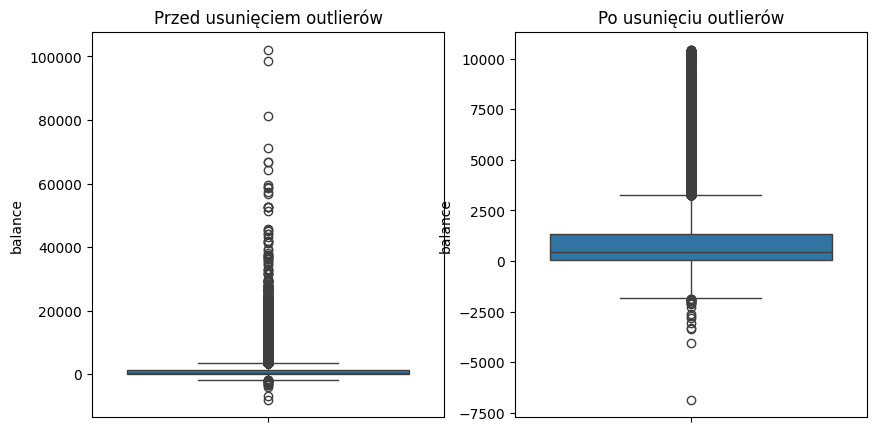

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=dataset2['balance'])
plt.title("Przed usunięciem outlierów")

plt.subplot(1, 2, 2)
sns.boxplot(y=dataset3['balance'])
plt.title("Po usunięciu outlierów")


#### Tworzenie nowych kolumn


W tym kroku zmieniam nazwę zmiennej docelowej, zamieniam odpowiedź `yes/no` na wartości binarne oraz przeliczam czas rozmowy z sekund na minuty.


In [13]:
# Zmiana nazwy kolumny 'y' na 'response'
dataset4.rename(index=str, columns={'y': 'response'}, inplace = True)

# Zamiana odpowiedzi yes/no na wartości 1/0, aby można było liczyć korelacje i wskaźniki.
def convert(dataset4, new_column, old_column):
    dataset4[new_column] = dataset4[old_column].apply(lambda x: 0 if x == 'no' else 1)
    return dataset4[new_column].value_counts()

convert(dataset4, "response_binary", "response")


response_binary
0    37785
1     4870
Name: count, dtype: int64

In [14]:
# Usunięcie kolumny 'contact', ponieważ nie jest używana w dalszej analizie
dataset5 = dataset4.drop('contact', axis=1)


In [15]:
# Przeliczenie czasu rozmowy z sekund na minuty
dataset5['duration'] = dataset5['duration'].apply(lambda n:n/60).round(2)


In [16]:
# Zamiana nazw miesięcy na numery miesięcy
lst = [dataset5]
for column in lst:
    column.loc[column["month"] == "jan", "month_int"] = 1
    column.loc[column["month"] == "feb", "month_int"] = 2
    column.loc[column["month"] == "mar", "month_int"] = 3
    column.loc[column["month"] == "apr", "month_int"] = 4
    column.loc[column["month"] == "may", "month_int"] = 5
    column.loc[column["month"] == "jun", "month_int"] = 6
    column.loc[column["month"] == "jul", "month_int"] = 7
    column.loc[column["month"] == "aug", "month_int"] = 8
    column.loc[column["month"] == "sep", "month_int"] = 9
    column.loc[column["month"] == "oct", "month_int"] = 10
    column.loc[column["month"] == "nov", "month_int"] = 11
    column.loc[column["month"] == "dec", "month_int"] = 12


#### Filtrowanie końcowe


In [17]:
# Usunięcie rozmów krótszych niż 5 sekund
condition2 = (dataset5['duration']<5/60)
dataset6 = dataset5.drop(dataset5[condition2].index, axis = 0, inplace = False)


In [18]:
# Usunięcie klientów z niejednoznaczną kategorią education = 'other'
condition3 = (dataset6['education'] == 'other')
dataset7 = dataset6.drop(dataset6[condition3].index, axis = 0, inplace = False)


## 3. Eksploracyjna analiza danych


W tej części sprawdzam rozkłady najważniejszych zmiennych oraz podstawowe zależności między nimi.


### 3.1 Rozkład wieku i salda


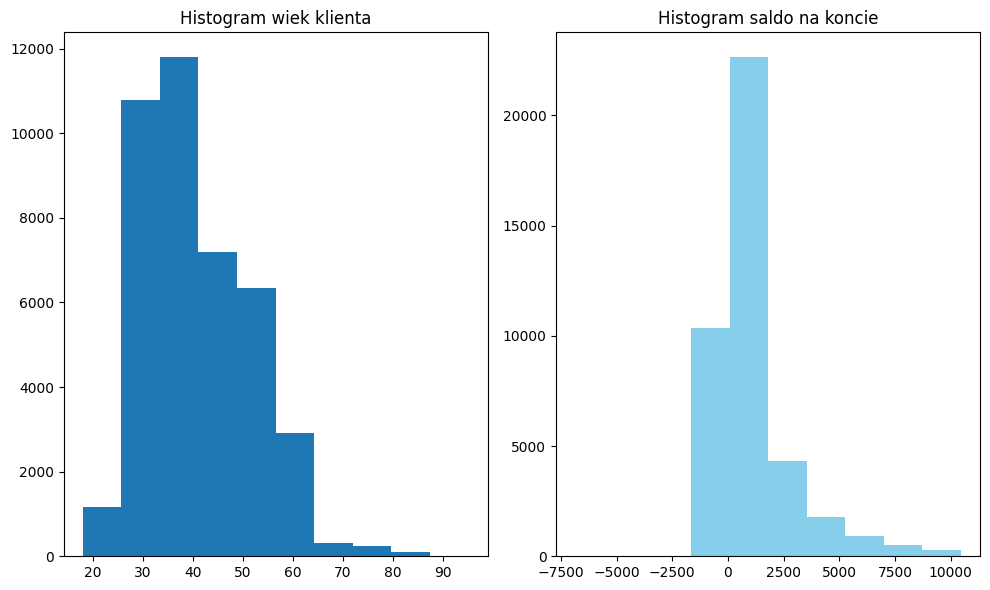

In [19]:
dist_age_balance = plt.figure(figsize = (10,6))

ra1 = dist_age_balance.add_subplot(1,2,1) 
ra2 = dist_age_balance.add_subplot(1,2,2)

ra1.hist(dataset7['age'])
ra1.set_title('Histogram wiek klienta')

ra2.hist(dataset7['balance'], color = 'skyblue')
ra2.set_title('Histogram saldo na koncie')

plt.tight_layout() 
plt.show()

Większość klientów znajduje się w średnich grupach wiekowych. Rozkład salda pokazuje, że większość klientów ma relatywnie niskie lub umiarkowane saldo.


Wykres salda pomaga ocenić, czy po usunięciu skrajnych obserwacji dane są bardziej czytelne i możliwe do dalszej analizy.


### 3.2 Zależność między wiekiem a saldem


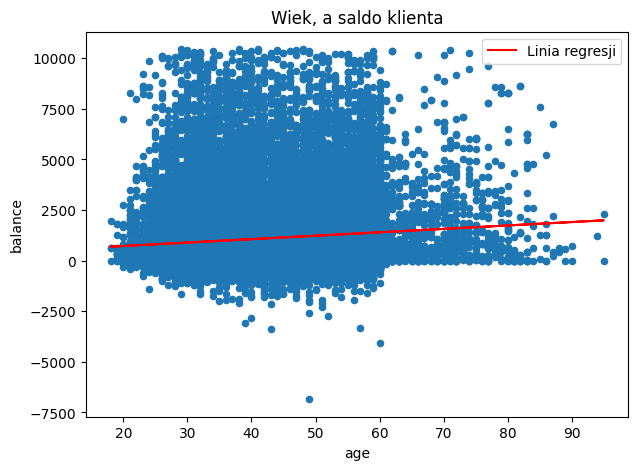

In [20]:
ax = dataset7.plot.scatter('age', 'balance', figsize=(7,5))

a, b = np.polyfit(dataset7['age'], dataset7['balance'], 1)

x_range = dataset7['age']
plt.plot(x_range, a * x_range + b, color='red', label='Linia regresji')

plt.title('Wiek, a saldo klienta')
plt.legend()
plt.show()

Na wykresie nie widać silnej zależności liniowej między wiekiem klienta a saldem na koncie.


### 3.3 Rozkład czasu rozmowy i liczby kontaktów


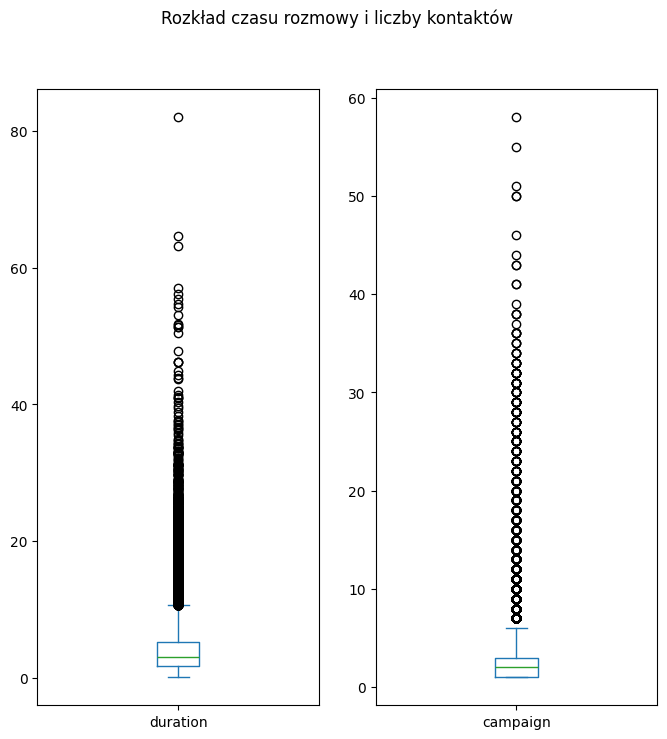

In [21]:
dist_dur_cam = dataset7[['duration','campaign']].plot(kind = 'box', 
                                                      figsize = (8,8),
                                                      subplots = True, layout = (1,2),
                                                      sharex = False, sharey = False,
                                                      title='Rozkład czasu rozmowy i liczby kontaktów')
plt.show()


Wykres pudełkowy pokazuje, że większość rozmów trwa krótko, ale występują też dłuższe rozmowy. Takie wartości mogą mieć znaczenie dla wyniku kampanii.


Zmienna `campaign` pokazuje, ile razy kontaktowano się z klientem w ramach kampanii. Duża liczba kontaktów może oznaczać mniejszą skuteczność lub trudniejszego klienta.


### 3.4 Czas rozmowy i liczba kontaktów a wynik kampanii


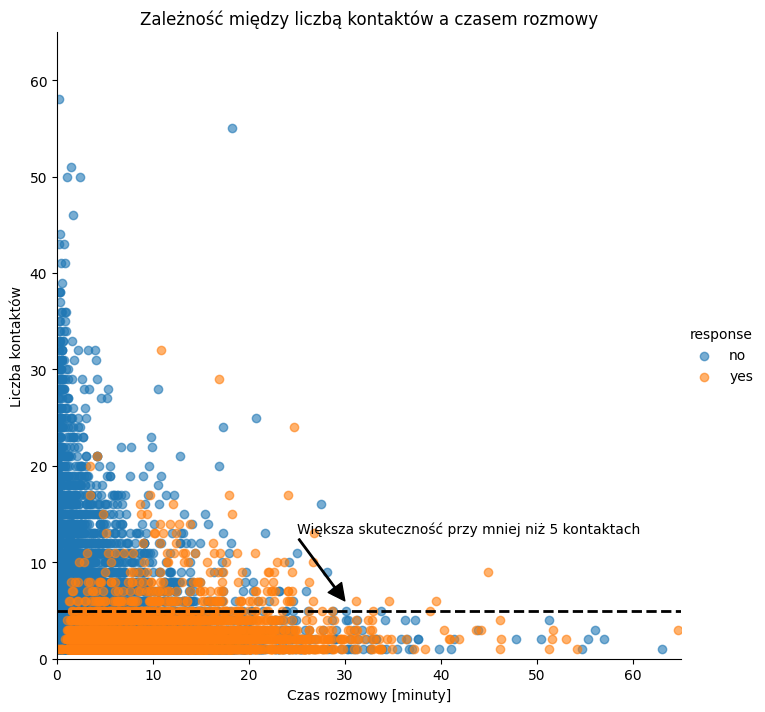

In [22]:
dur_cam = sns.lmplot(x='duration', y='campaign',data = dataset7,
                     hue = 'response',
                     fit_reg = False,
                     scatter_kws={'alpha':0.6}, height =7)

plt.axis([0,65,0,65])
plt.ylabel('Liczba kontaktów')
plt.xlabel('Czas rozmowy [minuty]')
plt.title('Zależność między liczbą kontaktów a czasem rozmowy')

# Linia pomocnicza pokazująca granicę 5 kontaktów
plt.axhline(y=5, linewidth=2, color="k", linestyle='--')
plt.annotate('Większa skuteczność przy mniej niż 5 kontaktach', xytext = (25,13),
             arrowprops=dict(color = 'k', width=1), xy=(30,6))
plt.show()


Kolor punktów pokazuje, czy klient zaakceptował ofertę. Dzięki temu można sprawdzić, czy klienci z dłuższymi rozmowami częściej odpowiadali pozytywnie.


### 3.5 Macierz korelacji


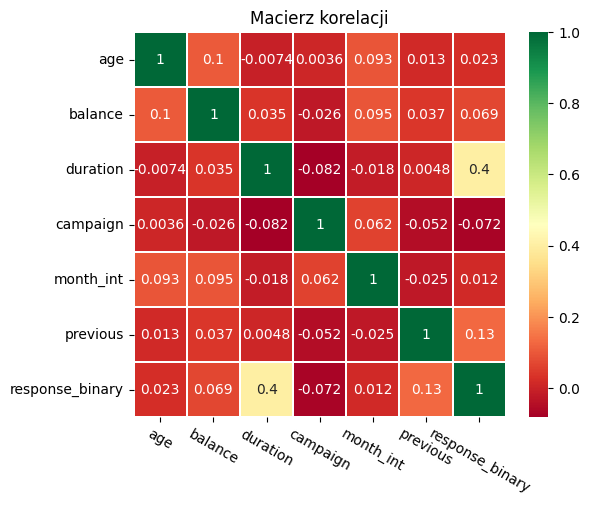

In [23]:
corr_data = dataset7[['age','balance','duration','campaign','month_int','previous','response_binary']]
corr = corr_data.corr()

cor_plot = sns.heatmap(corr,annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':10})
fig=plt.gcf()
fig.set_size_inches(6,5)
plt.xticks(fontsize=10,rotation=-30)
plt.yticks(fontsize=10)
plt.title('Macierz korelacji')
plt.show()


Macierz korelacji pozwala sprawdzić, które zmienne liczbowe są ze sobą powiązane. Największe znaczenie ma zależność zmiennych z `response_binary`.


## 4. Wizualizacja skuteczności kampanii


W tej części porównuję odsetek klientów, którzy zaakceptowali ofertę, w różnych grupach.


### 4.1 Skuteczność kampanii według wieku


In [24]:
dataset7['age_group'] = pd.cut(
    dataset7['age'],
    bins=[0, 29, 39, 49, 59, 100],
    labels=['<30', '30-39', '40-49', '50-59', '60+']
)

In [25]:
age_stats = dataset7.groupby('age_group').agg(
    liczba_osob=('age', 'count'),
    subscription_rate=('response', lambda x: (x == 'yes').mean() * 100)
).reset_index()

display(age_stats)

,age_group,liczba_osob,subscription_rate
0,<30,4745,16.986301
1,30-39,16566,10.364602
2,40-49,10528,8.824088
3,50-59,7514,9.182859
4,60+,1488,33.400538


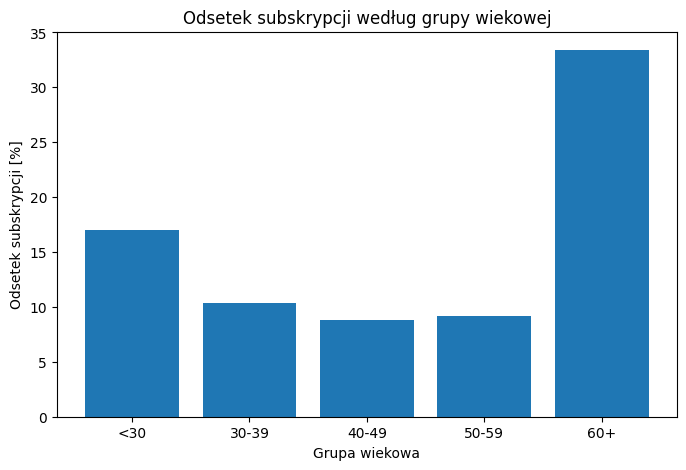

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(age_stats['age_group'], age_stats['subscription_rate'])

plt.title('Odsetek subskrypcji według grupy wiekowej')
plt.xlabel('Grupa wiekowa')
plt.ylabel('Odsetek subskrypcji [%]')

plt.show()


Wniosek: najmłodsze i najstarsze grupy klientów mogą mieć wyższy odsetek pozytywnych odpowiedzi niż część grup w średnim wieku.


### 4.2 Skuteczność kampanii według poziomu salda


In [27]:
dataset7 = dataset7.copy()

dataset7['balance_group'] = pd.cut(
    dataset7['balance'],
    bins=[-float('inf'), 0, 1000, 5000, float('inf')],
    labels=['no balance', 'low balance', 'average balance', 'high balance']
)

In [28]:
balance_stats = dataset7.groupby('balance_group').agg(
    contacted_count=('balance', 'count'),
    subscription_rate=('response', lambda x: (x == 'yes').mean() * 100)
).reset_index()

balance_stats['contacted_rate'] = (
    balance_stats['contacted_count'] / balance_stats['contacted_count'].sum() * 100
)

display(balance_stats)

,balance_group,contacted_count,subscription_rate,contacted_rate
0,no balance,6776,6.921488,16.591171
1,low balance,21398,10.734648,52.393428
2,average balance,10750,14.762791,26.321589
3,high balance,1917,14.919144,4.693813


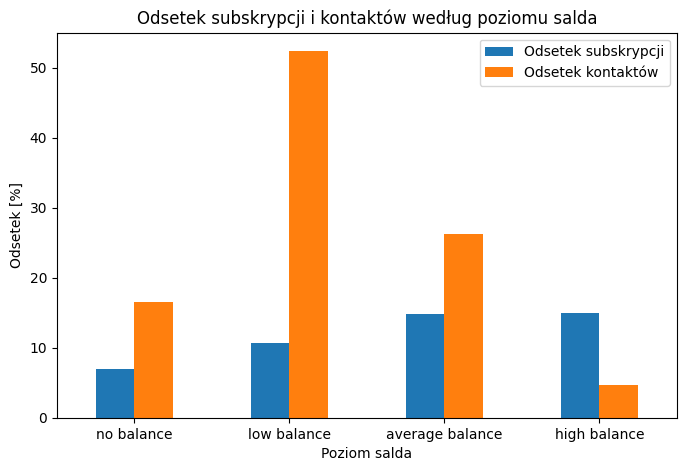

In [29]:
plot_data = balance_stats.set_index('balance_group')[['subscription_rate', 'contacted_rate']]

ax = plot_data.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Odsetek subskrypcji i kontaktów według poziomu salda')
plt.xlabel('Poziom salda')
plt.ylabel('Odsetek [%]')
plt.xticks(rotation=0)
plt.legend(['Odsetek subskrypcji', 'Odsetek kontaktów'])
plt.show()


Wniosek: klienci z wyższym lub średnim saldem mogą być bardziej atrakcyjną grupą docelową dla kampanii lokat.


### 4.3 Skuteczność według wieku i salda


In [30]:
age_balance1 = pd.DataFrame(dataset7.groupby(['age_group','balance_group'])['response_binary'].sum())
age_balance2 = pd.DataFrame(dataset7.groupby(['age_group','balance_group'])['response'].count())

age_balance1['response'] = age_balance2['response']
age_balance1['response_rate'] = age_balance1['response_binary']/ (age_balance1['response'])
age_balance1 = age_balance1.drop(['response_binary','response'],axis =1)

age_balance1 = age_balance1.unstack()

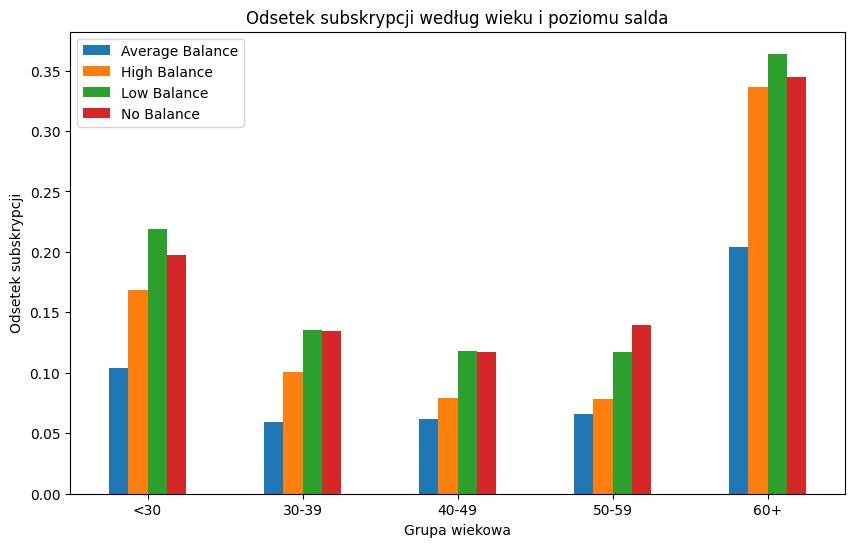

In [31]:
age_bal = age_balance1.plot(kind='bar',figsize = (10,6))

# Ustawienie podpisów osi X
plt.xticks(np.arange(5),('<30', '30-39', '40-49', '50-59', '60+'),rotation = 'horizontal')

# Ustawienie legendy
plt.legend(['Average Balance','High Balance','Low Balance','No Balance'],loc = 'best',ncol = 1)

plt.ylabel('Odsetek subskrypcji')
plt.xlabel('Grupa wiekowa')
plt.title('Odsetek subskrypcji według wieku i poziomu salda')
plt.show()


Wniosek: połączenie wieku i salda pozwala dokładniej wskazać grupy klientów, które najczęściej odpowiadają pozytywnie.


### 4.4 Skuteczność kampanii według zawodu


In [32]:
count_job_response_pct = pd.crosstab(dataset7['response'],dataset7['job']).apply(lambda x: x/x.sum() * 100)
count_job_response_pct = count_job_response_pct.transpose()

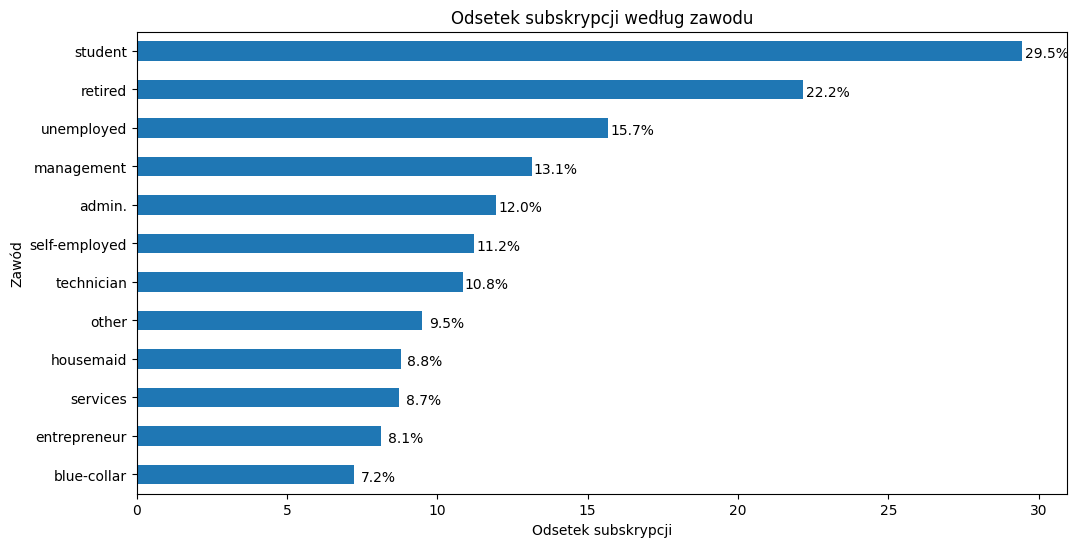

In [33]:
plot_job = count_job_response_pct['yes'].sort_values(ascending = True).plot(kind ='barh',
                                                                           figsize = (12,6))
                                                                               
plt.title('Odsetek subskrypcji według zawodu')
plt.xlabel('Odsetek subskrypcji')
plt.ylabel('Zawód')

# Dodanie wartości procentowych przy słupkach
for rec, label in zip(plot_job.patches,
                      count_job_response_pct['yes'].sort_values(ascending = True).round(1).astype(str)):
    plot_job.text(rec.get_width()+0.8, 
                  rec.get_y()+ rec.get_height()-0.5, 
                  label+'%', 
                  ha = 'center', 
                  va='bottom')


Wniosek: niektóre grupy zawodowe, np. studenci lub emeryci, mogą mieć wyższy odsetek subskrypcji niż pozostałe grupy.


### 4.5 Skuteczność kampanii według miesiąca


In [34]:
month_stats = dataset7.groupby('month_int').agg(
    contacted_count=('response', 'count'),
    subscription_rate=('response', lambda x: (x == 'yes').mean() * 100)
).reset_index()

month_stats['contacted_rate'] = (
    month_stats['contacted_count'] / month_stats['contacted_count'].sum() * 100
)

display(month_stats)

,month_int,contacted_count,subscription_rate,contacted_rate
0,1.0,1183,10.312764,2.896599
1,2.0,2258,17.271922,5.528758
2,3.0,407,54.299754,0.996548
3,4.0,2529,19.612495,6.192307
4,5.0,12496,6.610115,30.596704
5,6.0,4853,10.096847,11.882667
6,7.0,6520,8.466258,15.964350
7,8.0,5877,10.447507,14.389951
8,9.0,457,48.796499,1.118974
9,10.0,605,44.958678,1.481355


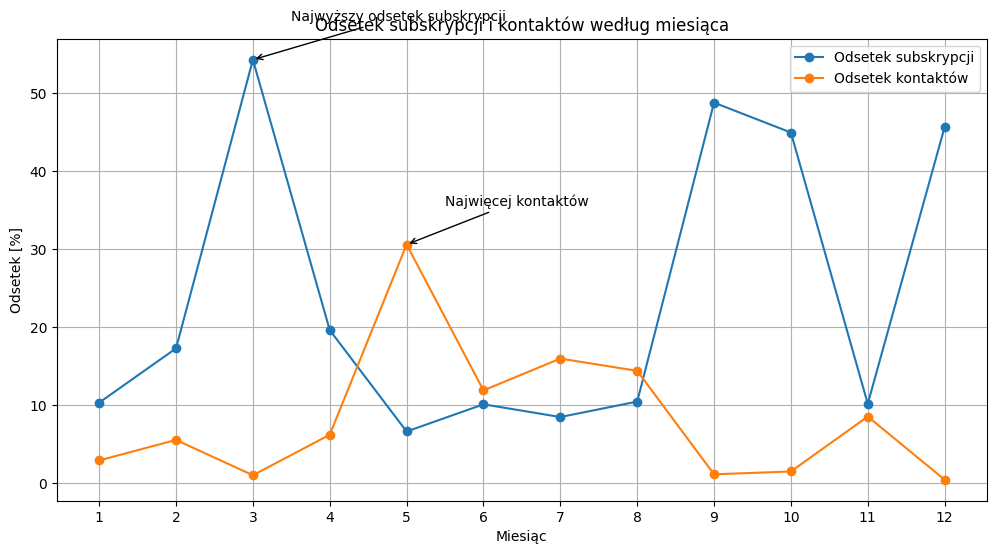

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(month_stats['month_int'], month_stats['subscription_rate'], marker='o', label='Odsetek subskrypcji')
plt.plot(month_stats['month_int'], month_stats['contacted_rate'], marker='o', label='Odsetek kontaktów')

max_sub = month_stats.loc[month_stats['subscription_rate'].idxmax()]
max_con = month_stats.loc[month_stats['contacted_rate'].idxmax()]

plt.annotate(
    'Najwyższy odsetek subskrypcji',
    xy=(max_sub['month_int'], max_sub['subscription_rate']),
    xytext=(max_sub['month_int'] + 0.5, max_sub['subscription_rate'] + 5),
    arrowprops=dict(arrowstyle='->')
)

plt.annotate(
    'Najwięcej kontaktów',
    xy=(max_con['month_int'], max_con['contacted_rate']),
    xytext=(max_con['month_int'] + 0.5, max_con['contacted_rate'] + 5),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Odsetek subskrypcji i kontaktów według miesiąca')
plt.xlabel('Miesiąc')
plt.ylabel('Odsetek [%]')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()


## 5. Podsumowanie

Analiza pokazuje, że skuteczność kampanii zależy od kilku cech klienta, m.in. wieku, salda, zawodu i miesiąca kontaktu. Takie informacje mogą pomóc bankowi lepiej dobierać grupę docelową i zwiększać efektywność kolejnych kampanii.
